# 01 - Preprocessing

Load the Grubman et al. (2019) entorhinal-cortex snRNA-seq matrix (GEO **GSE138852**),
attach the author metadata, compute QC metrics and normalise.

**No cells are filtered here.** The GEO matrix is already the authors' post-QC set, and every
downstream step - including the MapMyCells reference mapping, which was run once against these
exact 13,214 barcodes - is keyed to it. QC metrics are computed and plotted so the distributions
are on record, but the cell set is left intact.

Output: `interim/adata_lognorm.h5ad` - log1p(CP10K) counts, sparse.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))
from adpipe import *

import numpy as np
import pandas as pd
import scipy.sparse as sp
import scanpy as sc
import matplotlib.pyplot as plt

sc.settings.verbosity = 1
print("scanpy", sc.__version__)

scanpy 1.12.3


C:\Users\Admin\AppData\Local\Temp\ipykernel_3256\3753142111.py:12: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("scanpy", sc.__version__)


In [2]:
counts = pd.read_csv(RAW / "GSE138852_counts.csv.gz", index_col=0)
meta = pd.read_csv(RAW / "GSE138852_covariates.csv.gz", index_col=0)

print("counts (genes x cells):", counts.shape)
print("metadata:", meta.shape, "|", list(meta.columns))
counts.iloc[:4, :4]

counts (genes x cells): (10850, 13214)
metadata: (13214, 5) | ['oupSample.batchCond', 'oupSample.cellType', 'oupSample.cellType_batchCond', 'oupSample.subclustID', 'oupSample.subclustCond']


,AAACCTGGTAGAAAGG_AD5_AD6,AAACCTGGTAGCGATG_AD5_AD6,AAACCTGTCAGTCAGT_AD5_AD6,AAACCTGTCCAAACAC_AD5_AD6
FO538757.2,0,0,0,0
AP006222.2,0,0,0,0
RP5-857K21.4,0,0,0,0
RP11-206L10.9,0,0,0,0


In [3]:
# scanpy wants cells x genes
adata = sc.AnnData(X=sp.csr_matrix(counts.T.values.astype("float32")))
adata.obs_names = counts.columns
adata.var_names = counts.index
adata.var_names_make_unique()
adata.obs = meta.reindex(adata.obs_names)

del counts
print(adata)

AnnData object with n_obs × n_vars = 13214 × 10850
    obs: 'oupSample.batchCond', 'oupSample.cellType', 'oupSample.cellType_batchCond', 'oupSample.subclustID', 'oupSample.subclustCond'
    layers: None (.X)


In [4]:
# Raw counts are kept as a layer so later notebooks never have to re-read the CSV
adata.layers["counts"] = adata.X.copy()

adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)

print("mitochondrial genes detected:", int(adata.var["mt"].sum()))
adata.obs[["n_genes_by_counts", "total_counts", "pct_counts_mt"]].describe().round(2)

mitochondrial genes detected: 11


,n_genes_by_counts,total_counts,pct_counts_mt
count,13214.00,13214.00,13214.00
mean,701.95,1026.54,0.57
std,282.98,504.70,0.92
min,274.00,328.00,0.00
25%,498.00,669.00,0.08
50%,646.00,917.00,0.24
75%,852.00,1264.00,0.75
max,1632.00,2808.00,9.95


  figure -> results/figures/01_qc_metrics.png  (54 KB)


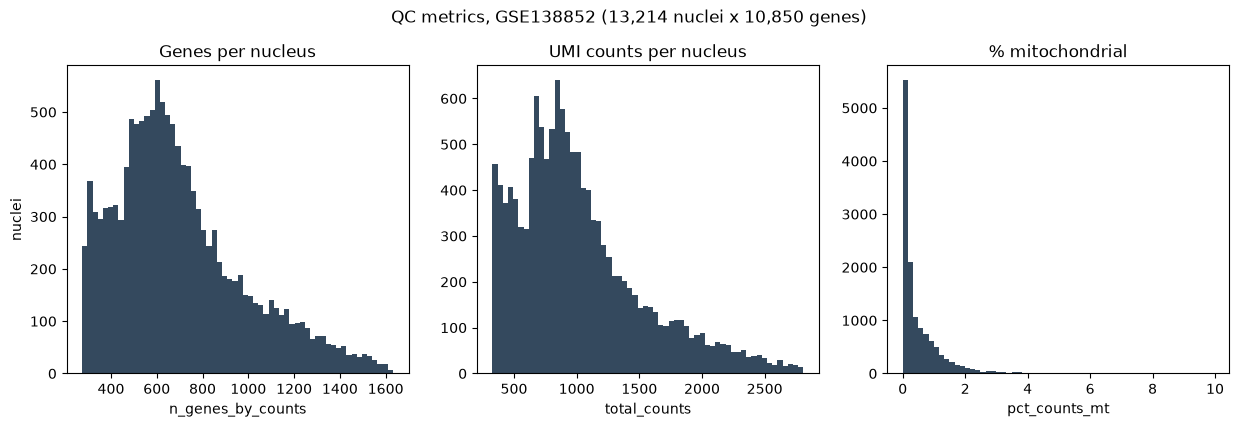

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(
    axes,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    ["Genes per nucleus", "UMI counts per nucleus", "% mitochondrial"],
):
    ax.hist(adata.obs[col], bins=60, color="#34495e")
    ax.set_title(title)
    ax.set_xlabel(col)
axes[0].set_ylabel("nuclei")
fig.suptitle(f"QC metrics, GSE138852 ({adata.n_obs:,} nuclei x {adata.n_vars:,} genes)", y=1.02)
save_fig(fig, "01_qc_metrics")
plt.show()

In [6]:
# What a conventional filter *would* have removed, for the record
would_drop = ((adata.obs["n_genes_by_counts"] < 200)
              | (adata.obs["pct_counts_mt"] > 20))
print(f"cells a <200-gene / >20% MT filter would drop: {int(would_drop.sum())} "
      f"({100 * would_drop.mean():.2f}%)  -  not applied, see notebook header")

cells a <200-gene / >20% MT filter would drop: 0 (0.00%)  -  not applied, see notebook header


In [7]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

print("X is now log1p(CP10K):", adata.X.dtype, "max", round(float(adata.X.max()), 3),
      "| sparse:", sp.issparse(adata.X))

adata.write(INTERIM / "adata_lognorm.h5ad")
print("interim ->", (INTERIM / "adata_lognorm.h5ad").relative_to(ROOT),
      f"({(INTERIM / 'adata_lognorm.h5ad').stat().st_size / 1e6:.0f} MB)")

X is now log1p(CP10K): float32 max 8.502 | sparse: True


interim -> interim\adata_lognorm.h5ad (150 MB)


In [8]:
qc = adata.obs.groupby("oupSample.batchCond", observed=True).agg(
    n_nuclei=("total_counts", "size"),
    median_genes=("n_genes_by_counts", "median"),
    median_umis=("total_counts", "median"),
    median_pct_mt=("pct_counts_mt", "median"),
)
save_table(qc, "01_qc_summary")
qc.round(2)

  table -> results/tables/01_qc_summary.tsv  (2 rows x 4 cols, 0 KB)


,n_nuclei,median_genes,median_umis,median_pct_mt
oupSample.batchCond,,,,
AD,6673,581.0,792.0,0.53
ct,6541,711.0,1035.0,0.13
